# Cotizaciones óptimas de un formador de mercado

### Modelo de Copeland y Galai (1983)

**Microestructuras y Sistemas de Trading** — ITESO, Otoño 2026

Laboratorio 01 · **Equipo 6**

Gonzalo Cano · Milca Correa

In [1]:
import sys, pathlib
for c in (pathlib.Path.cwd(), pathlib.Path.cwd().parent):
    if (c / "src").is_dir() and str(c) not in sys.path:
        sys.path.insert(0, str(c)); break

import matplotlib.pyplot as plt
import pandas as pd

# Tipografía grande: las figuras tienen que leerse desde el fondo del salón.
# Figuras compactas pero de tipografia grande: tienen que caber en una
# diapositiva y leerse desde el fondo del salon.
plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "axes.labelsize": 13,
                     "legend.fontsize": 11, "figure.dpi": 62})

from src.model import (S0, PI_I, ALPHA, BETA, SEED, analisis_sensibilidad,
                       curva_teorica_spread, distribucion_valor, optimizar_cotizaciones,
                       perdida_informados, utilidad_esperada, verificar_optimo_en_malla)
from src.simulation import (construir_regimenes, monte_carlo_regimenes,
                            resumen_monte_carlo, simular_regimenes, simular_trades)
from src.plots import (ETIQUETAS_REGIMEN, fig_histograma_montecarlo, fig_inventario, fig_pnl_acumulado,
                       fig_prob_ejecucion, fig_sensibilidad)

optimo = optimizar_cotizaciones()
regimenes = construir_regimenes(optimo["bid"], optimo["ask"])
simulaciones = simular_regimenes(regimenes, n_trades=10_000, seed=SEED)
resultados_mc = monte_carlo_regimenes(regimenes, n_corridas=1_000, n_trades=1_000, seed=SEED)
df_sensibilidad = analisis_sensibilidad()

## 1 · El problema

Un formador de mercado publica **Bid** y **Ask** alrededor de `S0 = 19.90`.

**No sabe quién va a cruzar.**

| Quién llega | Con qué probabilidad | Qué le deja al formador |
|---|---|---|
| Trader de **liquidez** | 0.60 | Gana el medio spread |
| Trader **informado** | 0.40 | **Pierde**: solo opera si el precio está mal |

El valor verdadero es `P ~ Erlang(k=60, λ=3)` — media **20.00**, desviación **2.58**.

`S0` está **0.10 por debajo** del valor esperado. Ese sesgo no es accidental.

## 2 · El modelo

$$\Pi(A,B) = \underbrace{\pi_L\left[\pi_{LB}(A{-}S_0)(A{-}S_0) + \pi_{LS}(S_0{-}B)(S_0{-}B)\right]}_{\text{ganancia frente a liquidez}} - \underbrace{\pi_I\left[\int_A^{\infty}(P{-}A)f(P)dP + \int_0^{B}(B{-}P)f(P)dP\right]}_{\text{pérdida frente a informados}}$$

**El trade-off:** ensanchar el spread sube lo que se gana por trade y baja lo que se pierde
frente a informados — pero también **espanta liquidez**.

$$\pi_{LB}(s) = \pi_{LS}(s) = \max(0,\ 0.50 - 0.08\,s)$$

## 3 · El trade-off, en una figura

A partir de un medio spread de **6.25** ya no queda nadie dispuesto a cruzar.

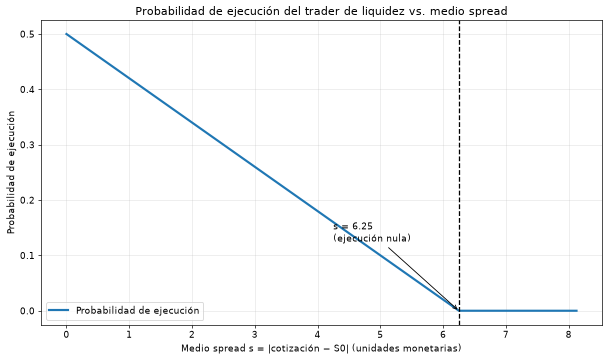

In [2]:
fig_prob_ejecucion();

## 4 · Las cotizaciones óptimas

Integrales con `scipy.integrate.quad` · optimización de $-\Pi(A,B)$ con `scipy.optimize.minimize`

In [3]:
malla = verificar_optimo_en_malla(optimo)
pd.Series({
    "Bid óptimo  B*":              f"{optimo['bid']:.2f}",
    "Ask óptimo  A*":              f"{optimo['ask']:.2f}",
    "Spread":                      f"{optimo['spread']:.2f}",
    "Utilidad esperada por trade": f"{optimo['utilidad_esperada']:.2f}",
    "":                            "",
    "Verificación en malla fina":  f"coincide dentro de {malla['dif_ask']:.4f}",
    "Condición de primer orden":   "resuelta aparte con brentq",
    "Pruebas con pytest":          "16 / 16",
}).to_frame(" ")

,
Bid óptimo B*,16.45
Ask óptimo A*,23.43
Spread,6.98
Utilidad esperada por trade,0.84
,
Verificación en malla fina,coincide dentro de 0.0023
Condición de primer orden,resuelta aparte con brentq
Pruebas con pytest,16 / 16


## 5 · ¿Por qué hace falta un spread?

### El régimen estrecho lo responde: 19.75 / 20.05

| | |
|---|---:|
| Gana por cada trader de liquidez | **+0.15** |
| Pierde por cada informado que cruza | **−2.03** |
| Traders de liquidez por cada informado | **1.5** |
| Necesitaría, para empatar | **13.5** |

$$\pi_L \times 0.15 = 0.09 \qquad \text{contra} \qquad \pi_I \times 1.9089 = 0.76$$

**La pérdida es 8.5× la ganancia.** Cierra en **−6,888** y pierde en **las 1,000 corridas**.

## 6 · El costo de la selección adversa cae con el spread

Pérdida esperada frente a informados, a medio spread simétrico creciente:

In [4]:
base = sum(perdida_informados(S0 + 0.15, S0 - 0.15))
filas = []
for s in (0.15, 0.50, 1.50, 3.00, 4.00):
    total = sum(perdida_informados(S0 + s, S0 - s))
    filas.append({"Medio spread": f"{s:.2f}",
                  "Pérdida esperada": f"{total:.4f}",
                  "vs. estrecho": "—" if s == 0.15 else f"{total / base - 1:+.0%}"})
pd.DataFrame(filas).set_index("Medio spread")

,Pérdida esperada,vs. estrecho
Medio spread,,
0.15,1.9089,—
0.50,1.5940,-16%
1.50,0.8947,-53%
3.00,0.3129,-84%
4.00,0.1375,-93%


**Convexa, no proporcional** — es la cola de una Erlang. **Y nunca llega a cero.**

## 7 · Tres regímenes, 10,000 trades

In [5]:
filas = []
for nombre, df in simulaciones.items():
    filas.append({
        "Régimen": ETIQUETAS_REGIMEN[nombre],
        "P&L total": f"{df['pnl'].sum():,.0f}",
        "Frente a liquidez": f"{df.loc[df.tipo_trader == 'liquidez', 'pnl'].sum():,.0f}",
        "Frente a informados": f"{df.loc[df.tipo_trader == 'informado', 'pnl'].sum():,.0f}",
    })
pd.DataFrame(filas).set_index("Régimen")

,P&L total,Frente a liquidez,Frente a informados
Régimen,,,
Óptimo,"19,912","20,810",-898
Estrecho,"-6,888",895,"-7,783"
Amplio,"5,246","8,949","-3,703"


**La columna de informados es negativa en los tres, siempre.**

## 8 · P&L acumulado

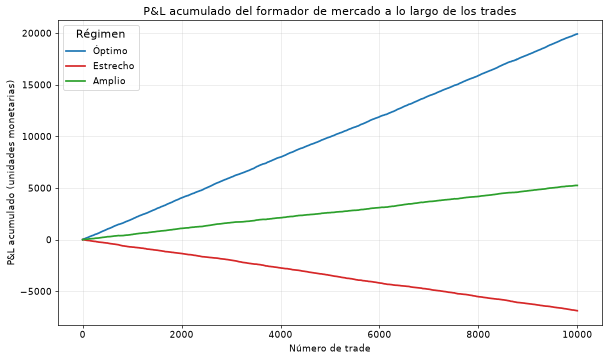

In [6]:
fig_pnl_acumulado(simulaciones);

## 9 · ¿Quién acumula más inventario? El óptimo

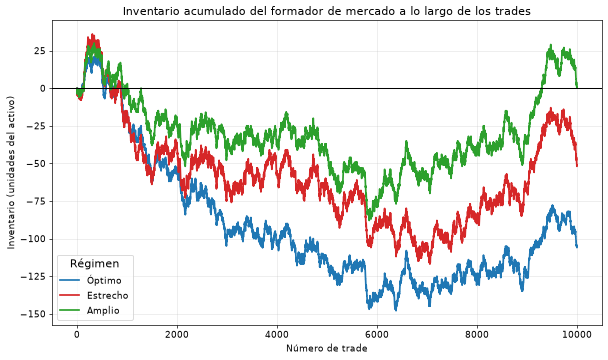

In [7]:
fig_inventario(simulaciones);

Todo viene de **informados**: **1.25 compras por cada venta**. Queda **corto justo cuando el activo vale más**.

## 10 · Monte Carlo — 1,000 corridas × 1,000 trades

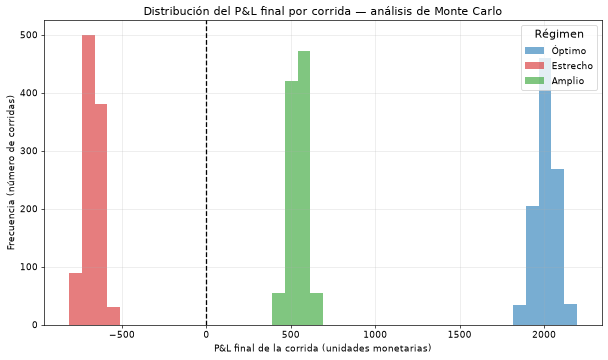

In [8]:
fig_histograma_montecarlo(resultados_mc);

Probabilidad de pérdida: **Óptimo 0%** · **Estrecho 100%** · **Amplio 0%**

## 11 · Sensibilidad: el modelo contra la teoría

Los puntos son `minimize`. La curva es la **condición de primer orden** resuelta con `brentq`.
Dos métodos sin fuente de error común: coinciden en **1e−6**.

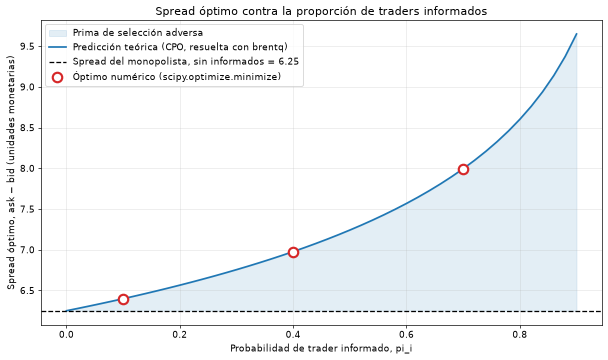

In [9]:
fig_sensibilidad(df_sensibilidad, curva_teorica_spread());

## 12 · Limitaciones y advertencia

**⚠ Rentabilidad por trade, no por unidad de tiempo.** Forzar la ejecución infla el P&L
del óptimo de **0.84 a 1.99 — 2.37×**.

1. **No hay riesgo de inventario** — las −105 unidades no entran en $\Pi(A,B)$
2. **Nunca aprende del flujo** — `S0` fijo pese a 404 informados comprando al ask
3. **Monopolio sin fricciones** — el spread es el **35% del valor del activo**

## Conclusiones

### El spread no es un margen comercial. Es el precio de una opción que se regala.

$$a^{*} = \underbrace{3.125}_{\text{monopolista}} + \underbrace{\frac{\pi_I}{\pi_L}\cdot\frac{1-F(A^{*})}{2\beta}}_{\text{prima de selección adversa}}$$

- El **piso de 3.125** existiría aunque no hubiera un solo informado
- Con $\pi_I = 0.7$, **el 23.8%** del medio spread es prima de información
- Cotizar cerca no protege: **expone**

### ¿Preguntas?